MNIST 데이터를 이용하여 손글씨를 식별하는 DNN 구축하기.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, models
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D
from tensorflow.keras.utils import plot_model

print(tf.__version__)

2.9.2


In [2]:
mnist = datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()
#fashion_mnist = datasets.fashion_mnist
#(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()
train_x = train_x/255.0
test_x = test_x/255.0

print(train_x.shape)

11490434/11490434 [==============================] - 2s 0us/step
(60000, 28, 28)


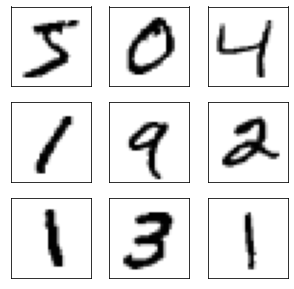

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
for col1 in range(9):
  plt.subplot(3,3,col1+1)
  plt.imshow(train_x[col1], cmap=plt.cm.binary)
  plt.xticks([])
  plt.yticks([])
plt.show()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 300)               90300     
                                                                 
 dense_2 (Dense)             (None, 10)                3010      
                                                                 
Total params: 328,810
Trainable params: 328,810
Non-trainable params: 0
_________________________________________________________________


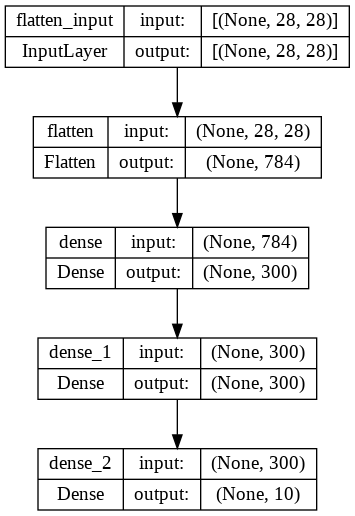

In [4]:
model = models.Sequential([
  Flatten(input_shape=(28,28)),
  Dense(300, activation='relu'),
  Dense(300, activation='relu'),
  Dense(10, activation='softmax')]
)
model.summary()

plot_model(model, to_file='model_mnist.png', show_shapes=True)

In [5]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist=model.fit(train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
540/540 [==============================] - 4s 3ms/step - loss: 0.2492 - accuracy: 0.9262 - val_loss: 0.1051 - val_accuracy: 0.9703
Epoch 2/20
540/540 [==============================] - 2s 4ms/step - loss: 0.0923 - accuracy: 0.9723 - val_loss: 0.0728 - val_accuracy: 0.9775
Epoch 3/20
540/540 [==============================] - 2s 3ms/step - loss: 0.0588 - accuracy: 0.9814 - val_loss: 0.0789 - val_accuracy: 0.9757
Epoch 4/20
540/540 [==============================] - 2s 3ms/step - loss: 0.0434 - accuracy: 0.9857 - val_loss: 0.0766 - val_accuracy: 0.9773
Epoch 5/20
540/540 [==============================] - 2s 3ms/step - loss: 0.0327 - accuracy: 0.9891 - val_loss: 0.0762 - val_accuracy: 0.9777
Epoch 6/20
540/540 [==============================] - 2s 4ms/step - loss: 0.0257 - accuracy: 0.9913 - val_loss: 0.0743 - val_accuracy: 0.9805
Epoch 7/20
540/540 [==============================] - 2s 3ms/step - loss: 0.0201 - accuracy: 0.9931 - val_loss: 0.0870 - val_accuracy: 0.9773
Epoch 

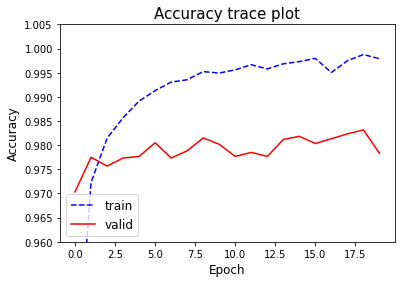

313/313 [==============================] - 1s 2ms/step - loss: 0.1377 - accuracy: 0.9757
...accuracy: 0.976, loss: 0.138


In [6]:
plt.plot(hist.history['accuracy'], 'b--', label='train')
plt.plot(hist.history['val_accuracy'], 'r-', label='valid')
plt.ylim([0.96,1.005])
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower left', fontsize=12)
plt.title('Accuracy trace plot', fontsize=15)
plt.show()

sc = model.evaluate(test_x, test_y)
print('...accuracy: %.3f, loss: %.3f'%(sc[1], sc[0]))

In [7]:
sc

[0.1377323567867279, 0.9757000207901001]